# **Operator_Dataset — interactive demo (users)**

## Libraries

In [13]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from torch.utils.data import DataLoader, random_split
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.image_operator import operator, DeepOperator, Operator
from datasets.operator_dataset import build_dataset, safe_collate
from core.base_converter import BaseConverter
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [14]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [15]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and apply some operators

In [16]:
image_array = io.read_image(images_path[rand], framework="numpy")      

image_noise_operator = operator(image_array, operator="noise", noise_level=0.5)

image_blurred_operator = operator(image_array, operator="blur", framework="torch", blur_level=0.3)

image_masked_operator, mask = operator(image_array, operator="inpaint", framework="torch", noise_level=0.5, threshold=0.8, mask_mode="grid_noised")

image_noise_Deep = operator(image_array, operator="noise", operator_class=DeepOperator, output_format="numpy", noise_level=0.5)

image_blurred_Deep = operator(image_array, operator="blur", operator_class=DeepOperator, output_format="numpy", blur_level=0.7)

image_masked_Deep = operator(image_array, operator="inpaint", operator_class=DeepOperator, output_format="numpy", noise_level=0.5, threshold=0.5, mask_mode="masked_noised")

## Visualisation

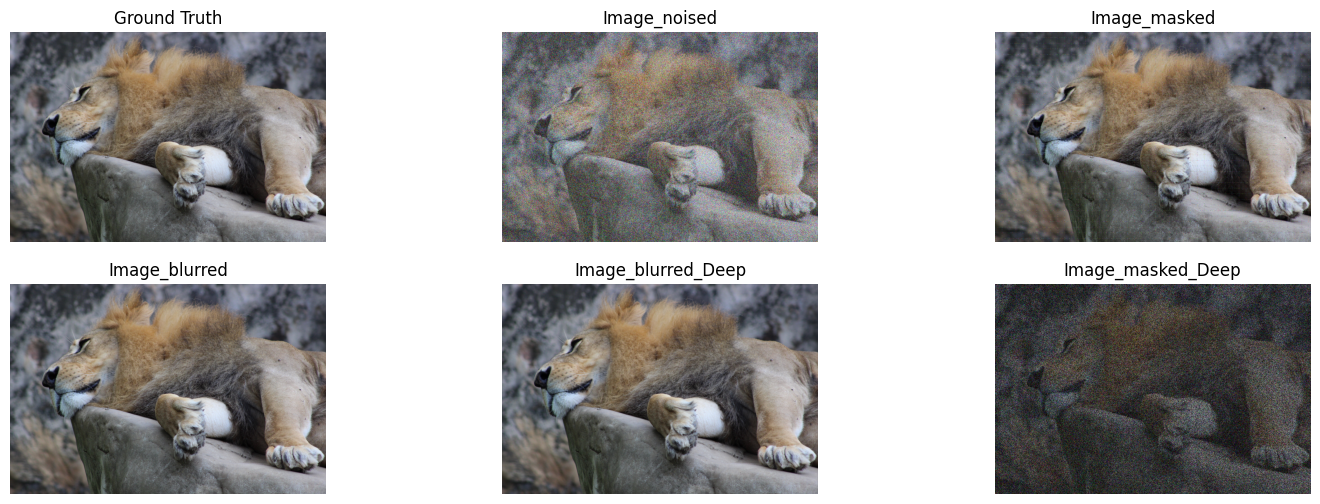

In [17]:
_, ((a,b,c), (d,e,f))  = plt.subplots(2, 3, figsize=(18,6))

show_plane(a, image_array, title="Ground Truth")
show_plane(b, image_noise_operator, title="Image_noised")
show_plane(c, image_masked_operator, title="Image_masked")
show_plane(d, image_blurred_operator, title="Image_blurred")
show_plane(e, image_blurred_Deep[0, :, :, :], title="Image_blurred_Deep")
show_plane(f, image_masked_Deep[0, :, :, :], title="Image_masked_Deep")

## Load Dataset

In [18]:
# Collect images
images_names = [img_path.name for img_path in root.rglob("*.png")]

# Create dataset 
degradation, return_transform = "noise", True

if return_transform:
    train_dataset, transform = build_dataset(dir_path=root, images_names=images_names, layout_framework="numpy", layout_name="HWC", 
                                operator=degradation, to_return="both", rotation=90, horizontal_flip=0.5, vertical_flip=0.5, return_param=True, return_transform=return_transform,)
else:
    train_dataset = build_dataset(dir_path=root, images_names=images_names, layout_framework="numpy", layout_name="HWC", 
                                operator=degradation, to_return="input", rotation=90, horizontal_flip=0.5, vertical_flip=0.5, return_param=False,)

# Split train / test / validation
num_train = int(len(train_dataset) * 0.95)
train_0, test = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

num_train_0 = int(len(train_0) * 0.9)
train, valid = random_split(train_0, [num_train_0, len(train_0) - num_train_0])

# Loaders
batch_size = 64
train_loader = DataLoader(dataset=train, batch_size=batch_size, shuffle=False, collate_fn=safe_collate)
valid_loader = DataLoader(dataset=valid, batch_size=batch_size, shuffle=False, collate_fn=safe_collate)
test_loader = DataLoader(dataset=test, batch_size=batch_size, shuffle=False, collate_fn=safe_collate)

# Extract first batch
data_iter = iter(train_loader)
sample_batch = next(data_iter)

# Extract images
images_noised, images_truth = sample_batch["input"], sample_batch["truth"]

if all(key in sample_batch for key in ["t_input", "t_truth"]):
    t_images_noised, t_images_truth = sample_batch["t_input"], sample_batch["t_truth"]

if return_transform and (key in sample_batch for key in ["t_params"]):
    t_params = sample_batch["t_params"]

## Dataset Visualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.4522972..4.5390735].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00052198337..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.249268..3.9343476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.3373241..3.8772786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.319447..4.121763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.3614826..4.30

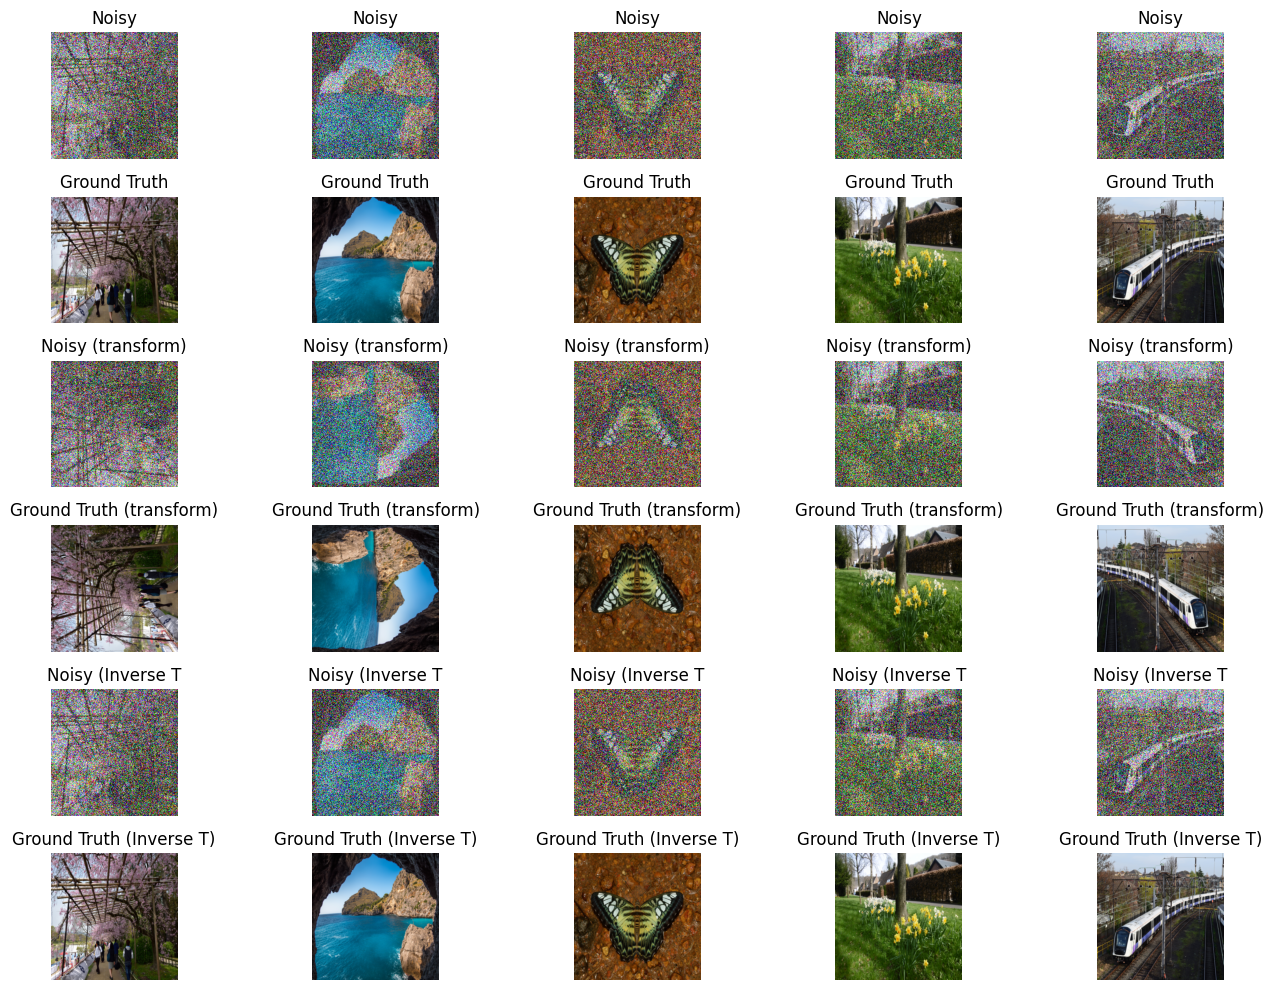

In [19]:
# Convert to numpy  
converter = BaseConverter(layout_cfg=LayoutConfig(layout_name="HWC", layout_framework="numpy",),       
                          global_cfg=GlobalConfig(framework="torch", output_format="numpy", add_batch_dim=True,),)
# Display
if all(key in sample_batch for key in ["t_input", "t_truth"]) and return_transform:
    fig, axes = plt.subplots(6, 5, figsize=(14, 10), dpi=100)
elif all(key in sample_batch for key in ["t_input", "t_truth"]):
    fig, axes = plt.subplots(4, 5, figsize=(12, 6), dpi=100)
else:
    fig, axes = plt.subplots(2, 5, figsize=(15, 4), dpi=100)

for i in range(5):
    axes[0, i].imshow(converter.tensor_to_numpy(images_noised[i]), cmap="gray")
    axes[0, i].set_title("Noisy")
    axes[0, i].axis("off")

    axes[1, i].imshow(converter.tensor_to_numpy(images_truth[i]), cmap="gray")
    axes[1, i].set_title("Ground Truth")
    axes[1, i].axis("off")
    
if all(key in sample_batch for key in ["t_input", "t_truth"]) :
    for i in range(5):
        axes[2, i].imshow(converter.tensor_to_numpy(t_images_noised[i]), cmap="gray")
        axes[2, i].set_title("Noisy (transform)")
        axes[2, i].axis("off")

        axes[3, i].imshow(converter.tensor_to_numpy(t_images_truth[i]), cmap="gray")
        axes[3, i].set_title("Ground Truth (transform)")
        axes[3, i].axis("off")
        
if return_transform and all(key in sample_batch for key in ["t_params"]):
    for i in range(5):
        axes[4, i].imshow(converter.tensor_to_numpy(transform.inverse(t_images_noised[i], t_params[i])), cmap="gray")
        axes[4, i].set_title("Noisy (Inverse T")
        axes[4, i].axis("off")

        axes[5, i].imshow(converter.tensor_to_numpy(transform.inverse(t_images_truth[i], t_params[i])), cmap="gray")
        axes[5, i].set_title("Ground Truth (Inverse T)")
        axes[5, i].axis("off")
        
plt.tight_layout()
plt.show()